In [3]:
# setup paths and libs
library(data.table)
library(ggplot2)
library(dplyr)
setwd('/well/lindgren/UKBIOBANK/flassen/projects/KO/wes_ko_ukbb/')

In [2]:
# protein coding genes
protein_coding <- fread('/well/lindgren/flassen/ressources/genesets/genesets/data/biomart/protein_coding_genes.tsv')
protein_coding <- protein_coding$ensembl_gene_id[protein_coding$gene_biotype == 'protein_coding']

# europeans
europeans <- fread('/well/lindgren/flassen/ressources/ukb/white_british/210921_ukbb_white_british_samples.txt')
europeans <- europeans$eid[europeans$in.white.British.ancestry.subset == 1]

# genetically europeans
europeans_gen <- fread('/well/lindgren/flassen/ressources/ukb/white_british/ukbb_genetically_european_nov2020_laura.txt')
europeans_gen <- europeans_gen$eid[europeans_gen$genetically_european == 1]

# get knockouts
ko_files = list.files('derived/knockouts/all/211013_ptv/', full.names = TRUE, pattern = 'knockouts')

# combine knockouts in single file
dt <- setDT(do.call(rbind, lapply(ko_files, function(f){
    d = fread(f)
    # = d[d$gene_id %in% protein_coding]
    name = basename(f)
    chr = as.numeric(gsub('chr','',unlist(lapply(strsplit(name, split = '_'), function(x) x[7]))))
    d$chr = chr
    return(d)
})))

In [4]:
d <- fread('derived/knockouts/all/211013_ptv//ukb_wes_200k_af02_chr3_knockouts.tsv.gz')
d[d$csqs == 'CH',]

gene_id,s,phase1,phase2,knockout,csqs
<chr>,<int>,<chr>,<chr>,<lgl>,<chr>
ENSG00000008226,2023782,"[""chr3_38093706_C_T""]","[""chr3_38120487_T_TATCA""]",TRUE,CH
ENSG00000008226,3603177,"[""chr3_38108443_C_CT""]","[""chr3_38122115_C_CCAAA""]",TRUE,CH
ENSG00000008226,4198138,"[""chr3_38120547_G_GGA""]","[""chr3_38097234_ACTGC_A""]",TRUE,CH
ENSG00000114654,4647867,"[""chr3_129002277_CTGCGCGCCGCGCTGCAGAGCAGTGA_C""]","[""chr3_129037032_T_TG""]",TRUE,CH
ENSG00000127252,5503321,"[""chr3_193263236_G_A""]","[""chr3_193255790_G_A""]",TRUE,CH
ENSG00000136059,4852289,"[""chr3_38002394_A_C""]","[""chr3_38004400_G_A""]",TRUE,CH
ENSG00000144596,4588310,"[""chr3_14517771_C_T""]","[""chr3_14540371_CT_C""]",TRUE,CH
ENSG00000144649,3518112,"[""chr3_43056318_C_T""]","[""chr3_43032909_C_T""]",TRUE,CH
ENSG00000144771,1098377,"[""chr3_54918482_GCT_G""]","[""chr3_54918600_CA_C""]",TRUE,CH


In [5]:
# setup overall stats
samples = unique(dt$s)
genes = unique(dt$gene_id)
print(paste(length(samples),'samples and',length(genes),'protein coding genes'))

[1] "181200 samples and 15589 protein coding genes"


In [6]:
sum(dt$csqs=='HO')

[1] 177

`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.

`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.



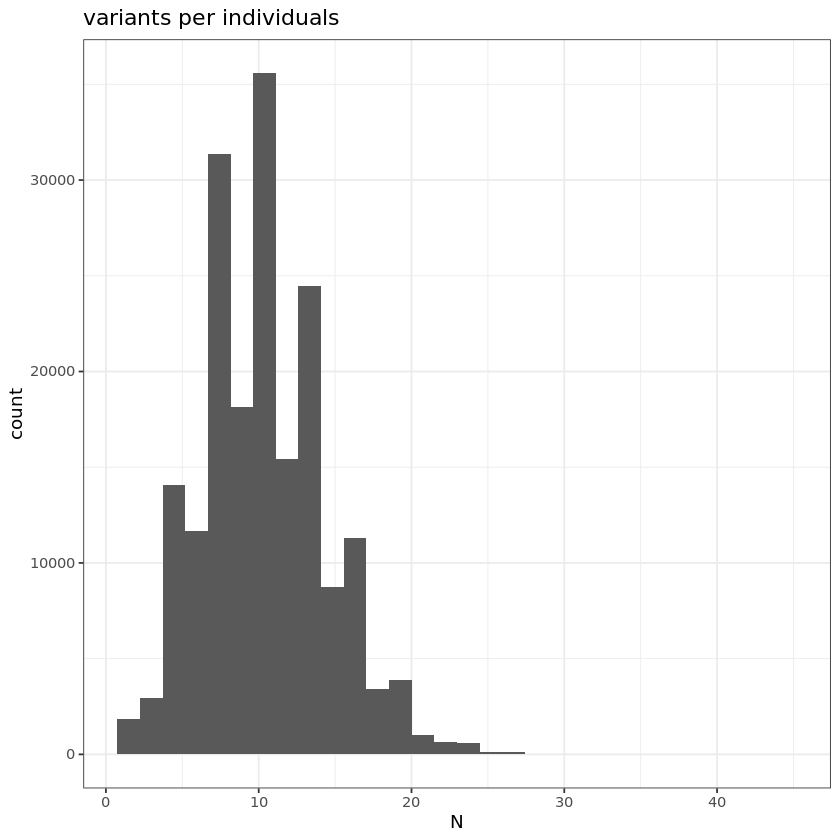

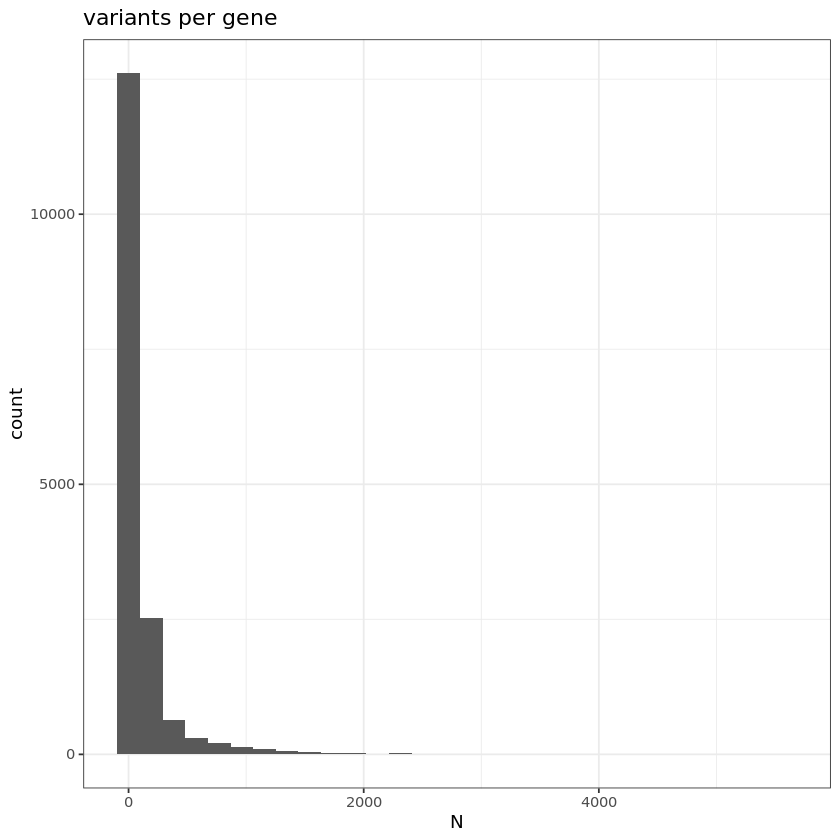

In [5]:
# how many genes are affected per individual
ind_count = as.data.table(table(dt$s))
ggplot(ind_count, aes(x=N)) + 
  geom_histogram() + 
  theme_bw() + 
  ggtitle('variants per individuals')

# how many genes are affected per individual
gene_count = as.data.table(table(dt$gene_id))
ggplot(gene_count, aes(x=N)) + 
  geom_histogram() + 
  theme_bw() + 
  ggtitle('variants per gene')

# Counting number of human kncokouts in UKBB (WES)

In [6]:
# knockouts
knockouts = length(unique(dt[dt$knockout == 1]$s))
homozygous = length(unique(dt[dt$knockout == 1 & dt$csqs == 'HO']$s))
compound_heterozygous = length(unique(dt[dt$knockout == 1 & dt$csqs == 'CH']$s))
both = length(unique(dt[dt$knockout == 1 & dt$csqs == 'CH+HO']$s))
n = length(unique(dt$s))
col_all = c(n, homozygous, compound_heterozygous, knockouts)

# Knockout genetically confirmed europeans
knockouts_gen_eur = length(unique(dt[dt$knockout == 1 & dt$s %in% europeans_gen]$s))
homozygous_gen_eur = length(unique(dt[dt$knockout == 1 & dt$csqs == 'HO' & dt$s %in% europeans_gen]$s))
compound_heterozygous_gen_eur = length(unique(dt[dt$knockout == 1 & dt$csqs == 'CH' & dt$s %in% europeans_gen]$s))
both_gen_eur = length(unique(dt[dt$knockout == 1 & dt$csqs == 'CH+HO' & dt$s %in% europeans_gen]$s))
n_gen_eur = sum(europeans_gen %in% dt$s)
col_eur_gen <- c(n_gen_eur, homozygous_gen_eur, compound_heterozygous_gen_eur, knockouts_gen_eur)

# knockouts EUR
knockouts_eur = length(unique(dt[dt$knockout == 1 & dt$s %in% europeans]$s))
homozygous_eur = length(unique(dt[dt$knockout == 1 & dt$csqs == 'HO' & dt$s %in% europeans]$s))
compound_heterozygous_eur = length(unique(dt[dt$knockout == 1 & dt$csqs == 'CH' & dt$s %in% europeans]$s))
both_eur = length(unique(dt[dt$knockout == 1 & dt$csqs == 'CH+HO' & dt$s %in% europeans]$s))
n_eur = sum(europeans %in% dt$s)
col_eur <- c(n_eur, homozygous_eur, compound_heterozygous_eur, knockouts_eur)

# generate table
df <- data.frame(col_all, col_eur_gen, col_eur)
rownames(df) <- c('n','homozygous knockouts', 'compound heterozygous knockouts', 'total knockouts')
df

,col_all,col_eur_gen,col_eur
,<int>,<int>,<int>
n,185431,184167,166953
homozygous knockouts,258,255,228
compound heterozygous knockouts,4822,4789,4326
total knockouts,5070,5034,4545


In [7]:
# what genes are affected
n_genes = length(unique(dt$gene_id[dt$knockout==1]))
genes = table(dt$gene_id[dt$knockout==1])
print(paste(n_genes,'genes are found in human knockouts'))

[1] "3740 genes are found in human knockouts"


In [8]:
# Individuals that have multiple damaging alleles in a gene
dt[dt$csqs == 'CH+HO',]

gene_id,s,phase1,phase2,knockout,csqs,chr
<chr>,<int>,<chr>,<chr>,<lgl>,<chr>,<dbl>
ENSG00000118997,5634685,"[""chr2_195809819_G_A"",""chr2_195934670_A_G""]","[""chr2_195853501_G_A"",""chr2_195934670_A_G""]",TRUE,CH+HO,2
ENSG00000136068,3605608,"[""chr3_58077115_A_T"",""chr3_58123129_G_A""]","[""chr3_58123129_G_A"",""chr3_58136139_C_T""]",TRUE,CH+HO,3
ENSG00000004846,4039079,"[""chr7_20626612_G_C"",""chr7_20742998_T_C""]","[""chr7_20626612_G_C"",""chr7_20645861_C_A""]",TRUE,CH+HO,7
ENSG00000130653,4093262,"[""chr9_137497207_G_A"",""chr9_137522823_C_T""]","[""chr9_137522796_C_T"",""chr9_137522823_C_T""]",TRUE,CH+HO,9


# Assessing how many genes are involved in mendelian disorders

In [9]:
# load OMIM
omim_mapping <- fread('/well/lindgren/flassen//ressources/genesets/genesets/data/omim/mim2gene.txt')
colnames(omim_mapping) <- c('MIM','entry','entrez','hgnc_symbol','gene_id')
omim_knockouts <- omim_mapping[omim_mapping$gene_id %in% dt$gene_id[dt$knockout==1]]

In [10]:
# relate to mendelian disorderes
mim_map <- fread('/well/lindgren/flassen//ressources/genesets/genesets/data/omim/morbidmap.txt')
colnames(mim_map) <- c('phenotype','gene_symbols','MIM','cyto_location')
omim_merge <- merge(mim_map, omim_knockouts)

# count how many knockout genes are associated with a phenotype
print(paste(length(unique(omim_merge$gene_id)), 'genes associated with',length(unique(omim_merge$phenotype)),'phenotypes (OMIM)'))
print(paste(length(unique(omim_merge$gene_id)), 'genes associated with',length(unique(omim_merge$MIM)),'MIM numbers (OMIM)'))

Warning message in fread("/well/lindgren/flassen//ressources/genesets/genesets/data/omim/morbidmap.txt"):
"Stopped early on line 8087. Expected 4 fields but found 1. Consider fill=TRUE and comment.char=. First discarded non-empty line: <<#>>"


[1] "1211 genes associated with 2074 phenotypes (OMIM)"
[1] "1211 genes associated with 1211 MIM numbers (OMIM)"


In [11]:
# count how many samples are affected
ukbb_all_in_merge <- length(unique(dt$s[dt$knockout == 1 & dt$gene_id %in% omim_merge$gene_id]))
ukbb_gen_eur_in_merge <- length(unique(dt$s[dt$knockout == 1 & dt$gene_id %in% omim_merge$gene_id & dt$s %in% europeans_gen]))
ukbb_eur_in_merge <- length(unique(dt$s[dt$knockout == 1 & dt$gene_id %in% omim_merge$gene_id & dt$s %in% europeans]))

print(paste(ukbb_all_in_merge, 'WES samples (all) who have knockouts of OMIN genes'))
print(paste(ukbb_gen_eur_in_merge, 'WES samples (genetical european) who have knockouts of OMIN genes'))
print(paste(ukbb_eur_in_merge, 'WES samples (european) who have knockouts of OMIN genes'))

[1] "10135 WES samples (all) who have knockouts of OMIN genes"
[1] "6831 WES samples (genetical european) who have knockouts of OMIN genes"
[1] "6042 WES samples (european) who have knockouts of OMIN genes"


# Variant level summary

Here, we are investigating what type of variants are typically involved in a knockout. i.e. how often do we get compound hetz that has a damaging missense and a protein truncating variant:

In [127]:
# helpers
format_from_hail <- function(x) gsub('(\\[)|(\\])|(")|(\\})|(\\{)','',x)

# stratify by variant in long format
stratify_by_variant <- function(curdt){
   do.call(rbind, lapply(1:nrow(curdt), function(i){
    gene = curdt$gene_id[i]
    sample = curdt$s[i]
    knockout = curdt$knockout[i]
    phase1 = unlist(strsplit(format_from_hail(curdt$phase1[i]), split = ','))
    phase2 = unlist(strsplit(format_from_hail(curdt$phase2[i]), split = ','))
    outdt1 = data.table(gene = gene, sample = sample, phase = 1, knockout = knockout, snpid = phase1)
    outdt2 = data.table(gene = gene, sample = sample, phase = 2, knockout = knockout, snpid = phase2)
    return(rbind(outdt1, outdt2))
    })) 
}

# extract hail field
extract_hail_field <- function(data){
    
    n = length(data)
    # create a sub matrix for each row
    lst <- lapply(1:n, function(i){
        row <- strsplit(data[i], split = '\\,')[1]
        unlisted_row <- unlist(row)
        count_skip <- lengths(regmatches(unlisted_row, gregexpr(":", unlisted_row)))
        unlisted_row <- unlisted_row[count_skip == 1]
        matrix <- matrix(unlist(lapply(list(unlisted_row), function(x) strsplit(x, split = '\\:'))), nrow = 2)
        entries <- data.table(t(matrix[2,]))
        colnames(entries) <- matrix[1,]
        return(entries)
                                   
    })
                                
    # note that sub-matrices have different column names
    combined <- suppressMessages(dplyr::bind_rows(lst))
    combined <- combined[,!grepl('(name\\.\\.)|(db\\.\\.)',colnames(combined)), with = FALSE]
    return(combined)
}   
       
# a function to extract hail rows (specifically INFO and VEP field)
unpack_hail_rows <- function(data){
    info <- format_from_hail(dfv$info)
    vep <- format_from_hail(dfv$vep)
    #dbnsfp <- format_from_hail(dfv$dbnsfp)
    mat <- setDT(cbind(
        dfv[,c('locus','alleles','snpid','rsid')],
        extract_hail_field(info),
        extract_hail_field(vep)
        #extract_hail_field(dbnsfp)
    ))
    return(mat)
}
                        
# define consequence
PLOF_CSQS = c("transcript_ablation", "splice_acceptor_variant","splice_donor_variant", "stop_gained", "frameshift_variant")
MISSENSE_CSQS = c("stop_lost", "start_lost", "transcript_amplification", "inframe_insertion", "inframe_deletion", "missense_variant")
SYNONYMOUS_CSQS = c("stop_retained_variant", "synonymous_variant")
OTHER_CSQS = c("mature_miRNA_variant", "5_prime_UTR_variant","3_prime_UTR_variant", "non_coding_transcript_exon_variant", "intron_variant","NMD_transcript_variant", "non_coding_transcript_variant", "upstream_gene_variant","downstream_gene_variant", "TFBS_ablation", "TFBS_amplification", "TF_binding_site_variant","regulatory_region_ablation", "regulatory_region_amplification", "feature_elongation","regulatory_region_variant", "feature_truncation", "intergenic_variant")
                                
# add consequence category
annotate_csqs_category <- function(csqs){
    csqs[csqs %in% PLOF_CSQS] <- "ptv"
    csqs[csqs %in% MISSENSE_CSQS] <- "missense"
    csqs[csqs %in% SYNONYMOUS_CSQS] <- "synonymous"
    csqs[csqs %in% OTHER_CSQS] <- "non_coding"
    return(csqs)
}               
                                
# collapse to
collapse_to_most_severe_csqs_category <- function(df){
    if (! 'consequence_category' %in% colnames(df)) stop('consequence_category not found!')
    snpids <- unique(df$snpid)
    do.call(rbind, lapply(snpids, function(id){
        tmp <- df[df$snpid %in% id,]
        ptv_bool <- tmp$consequence_category %in% 'ptv'
        if (sum(ptv_bool)) return(tmp[ptv_bool,])
        missense_bool <- tmp$consequence_category == 'missense'
        if (sum(missense_bool)) return(tmp[missense_bool,])
        synonymous_bool <- tmp$consequence_category == 'synonymous'
        if (sum(synonymous_bool)) return(tmp[synonymous_bool,])
        non_coding_bool <- tmp$consequence_category == 'non_coding'
        if (sum(non_coding_bool)) return(tmp[non_coding_bool,])
    }))
}
                                
                                
# extract a field and combine it by gene x individual in a single cell                                
extract_field_by_gene_sample <- function(df, field = 'most_severe_consequence', delim = ';'){
    samples <- unique(df$sample)
    genes <- unique(df$gene)
    stopifnot(field %in% colnames(df))
    as.data.table(do.call(rbind, lapply(samples, function(s) 
        do.call(rbind, lapply(genes, function(g){
            outdf <- df[df$sample %in% s & df$gene %in% g, ]
            outdf <- data.frame(table(outdf[[field]]))
            if (nrow(outdf) > 0){
                return(data.table(s = s, gene = g, entry = paste0(outdf$Var1, collapse = delim)))
                }
    })))))
}
                

In [147]:
# investigating homozygous knockouts first
dt_ch <- dt[dt$csqs == 'CH' & dt$chr == '22']
head(dt_ch)

# stratify by varaint
dt_ch = stratify_by_variant(dt_ch)
#head(dt_ch)
print(paste(length(unique(dt_ch$snpid)),'damaging variants on the chromosome'))

# get Hail variants (note, this step takes a long time!)
dfv <- fread('data/variants/ukb_wes_200_chr22_variants.tsv.gz', stringsAsFactor = FALSE)
dfv <- dfv[dfv$snpid %in% dt_ch$snpid,]
#nrow(dfv)

# unpact damaging variants
stats <- unpack_hail_rows(dfv)
#head(stats)

gene_id,s,phase1,phase2,knockout,csqs,chr
<chr>,<int>,<chr>,<chr>,<lgl>,<chr>,<dbl>
ENSG00000014919,1107208,"[""chr10_99729614_G_A""]","[""chr10_99727030_C_T""]",TRUE,CH,10
ENSG00000014919,3553945,"[""chr10_99727002_C_T""]","[""chr10_99727507_G_A""]",TRUE,CH,10
ENSG00000014919,5601762,"[""chr10_99727030_C_T""]","[""chr10_99714667_C_T""]",TRUE,CH,10
ENSG00000023839,1327717,"[""chr10_99844350_C_T""]","[""chr10_99836218_G_T""]",TRUE,CH,10
ENSG00000023839,1360575,"[""chr10_99800532_G_A""]","[""chr10_99805400_A_G""]",TRUE,CH,10
ENSG00000023839,1507997,"[""chr10_99836218_G_T""]","[""chr10_99844350_C_T""]",TRUE,CH,10


[1] "12319 damaging variants on the chromosome"


## Compound Heterozygous variants

In [148]:
#stats
stats$consequence_category <- annotate_csqs_category(stats$most_severe_consequence)
stats_collapsed <- collapse_to_most_severe_csqs_category(stats)
stats_mrg <- merge(dt_ch, stats_collapsed, by = 'snpid')
stats_mrg[stats_mrg=='null'] <- NA
stats_mrg <- stats_mrg[order(stats_mrg$sample),]

In [149]:
# extract field by sample
df <- stats_mrg

In [150]:
#* How many CH knockouts consist of only PTVs?
#* How many CH knockouts consist of only missesnse variants? 
#* How many CH knockouts consist of both PTVs and missense variants?
tbl_consequence_category <- extract_field_by_gene_sample(df, field = 'consequence_category')
counts <- as.data.frame(table(tbl_consequence_category$entry))
counts$pct <- round( counts$Freq / sum(counts$Freq) , 4)*100
counts <- counts[order(counts$Freq),]
counts

,Var1,Freq,pct
,<fct>,<int>,<dbl>
4,missense;synonymous,4,1.29
2,missense;non_coding,7,2.26
6,ptv;synonymous,13,4.19
5,ptv,38,12.26
3,missense;ptv,52,16.77
1,missense,196,63.23


In [151]:
# summarize LoF counts
tbl_lof <- extract_field_by_gene_sample(df, field = 'lof')
counts_lof <- as.data.frame(table(tbl_lof$entry))
counts_lof$pct <- round( counts_lof$Freq / sum(counts_lof$Freq) , 4)*100
counts_lof <- counts_lof[order(counts_lof$Freq),]
counts_lof

,Var1,Freq,pct
,<fct>,<int>,<dbl>
2,HC;LC,1,0.97
3,LC,4,3.88
1,HC,98,95.15


In [152]:
# summarize LoF counts
tbl_csqs <- extract_field_by_gene_sample(df, field = 'most_severe_consequence')
counts_csqs<- as.data.frame(table(tbl_csqs$entry))
counts_csqs$pct <- round( counts_csqs$Freq / sum(counts_csqs$Freq) , 4)*100
counts_csqs <- counts_csqs[order(counts_csqs$Freq),]
counts_csqs

,Var1,Freq,pct
,<fct>,<int>,<dbl>
2,intron_variant;missense_variant,1,0.32
1,downstream_gene_variant;missense_variant,3,0.97
3,intron_variant;missense_variant;upstream_gene_variant,3,0.97
8,missense_variant;synonymous_variant,4,1.29
9,splice_acceptor_variant;splice_donor_variant,4,1.29
5,missense_variant;splice_acceptor_variant,6,1.94
11,splice_donor_variant;stop_gained,9,2.90
6,missense_variant;splice_donor_variant,12,3.87
10,splice_donor_variant,12,3.87


In [17]:
#map_snpid_to(stats_collapsed$snpid, stats_collapsed$consequence_category)
stats[stats$snpid %in% 'chr22_27990027_G_A']

locus,alleles,snpid,rsid,AF,AQ,AC,AN,ExcessHet,allele_num,⋯,uniparc,variant_allele,most_severe_consequence,csq_score,domains,lof_info,db,hgnc_id,name,consequence_category
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,⋯,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
chr22:27990027,"[""G"",""A""]",chr22_27990027_G_A,rs538665951,7.5076953877724665E-6,47,3,399590,3.0103,1,⋯,null,A,intron_variant,24.0,null,null,NA,NA,NA,non_coding
chr22:27990027,"[""G"",""A""]",chr22_27990027_G_A,rs538665951,7.5076953877724665E-6,47,3,399590,3.0103,1,⋯,null,A,upstream_gene_variant,28.0,null,null,NA,null,NA,non_coding
chr22:27990027,"[""G"",""A""]",chr22_27990027_G_A,rs538665951,7.5076953877724665E-6,47,3,399590,3.0103,1,⋯,null,A,upstream_gene_variant,28.0,null,null,NA,NA,NA,non_coding


In [75]:
print(paste(length(unique(stats_collapsed$snpid)),'unique SNPs when collapsing by most severe '))
#print(paste(sum(stats_collapsed$snpid %in% dt_ch$snpid)),'Collapsed SNPs in hetz data'))
#print(paste(length(unique(stats_collapsed$snpid)),'unique SNPs when collapsing by most severe '))
#table(stats$most_severe_consequence)
#stats_collapsed 
mapping[[1]]



[1] "271 unique SNPs when collapsing by most severe "


[1] "chr22_16591457_C_T"

In [45]:
#info <- extract_hail_field(format_from_hail(dfv$info))


dt_ch[dt_ch$snpid %in% "chr22_50574346_C_T", ]

#"chr22_50572219_A_G"

gene,sample,phase,knockout,snpid
<chr>,<int>,<dbl>,<lgl>,<list>
ENSG00000100288,1038793,2,TRUE,chr22_50574346_C_T
ENSG00000100288,2356140,2,TRUE,chr22_50574346_C_T
ENSG00000100288,3005552,1,TRUE,chr22_50574346_C_T
ENSG00000100288,3997325,1,TRUE,chr22_50574346_C_T
ENSG00000100288,5195711,1,TRUE,chr22_50574346_C_T
ENSG00000100288,5274052,2,TRUE,chr22_50574346_C_T
ENSG00000100288,5855436,1,TRUE,chr22_50574346_C_T
ENSG00000205560,1038793,2,TRUE,chr22_50574346_C_T
ENSG00000205560,2146654,2,TRUE,chr22_50574346_C_T


In [58]:
head(stats)

locus,alleles,snpid,rsid,AF,AQ,AC,AN,ExcessHet,allele_num,⋯,csq_score,domains,lof_info,db,hgnc_id,name,revel_score,cadd_phred_score,polyphen2_hdiv_pred,polyphen2_hvar_pred
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,⋯,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
chr22:16591457,"[""C"",""T""]",chr22_16591457_C_T,rs139948519,0.004643211149714149,52,1855,399508,21.4201,1,⋯,-497.0,NA,NA,NA,NA,NA,null,36.0,polyphen2_hvar_pred,NA
chr22:16591457,"[""C"",""T""]",chr22_16591457_C_T,rs139948519,0.004643211149714149,52,1855,399508,21.4201,1,⋯,29.0,null,null,NA,NA,NA,null,36.0,polyphen2_hvar_pred,NA
chr22:16591592,"[""C"",""T""]",chr22_16591592_C_T,chr22_16591592_C_T,2.352505418270458E-4,50,94,399574,3.058,1,⋯,-497.0,NA,NA,NA,NA,NA,null,34.0,polyphen2_hvar_pred,NA
chr22:16591592,"[""C"",""T""]",chr22_16591592_C_T,chr22_16591592_C_T,2.352505418270458E-4,50,94,399574,3.058,1,⋯,29.0,null,null,NA,NA,NA,null,34.0,polyphen2_hvar_pred,NA
chr22:16592288,"[""C"",""T""]",chr22_16592288_C_T,rs150143968,1.751804358489244E-5,44,7,399588,3.0105,1,⋯,-497.0,NA,NA,NA,NA,NA,null,33.0,polyphen2_hvar_pred,NA
chr22:16592288,"[""C"",""T""]",chr22_16592288_C_T,rs150143968,1.751804358489244E-5,44,7,399588,3.0105,1,⋯,29.0,null,null,NA,NA,NA,null,33.0,polyphen2_hvar_pred,NA


In [ ]:
mat <- setDT(cbind(
        dfv[,c('locus','alleles','snpid','rsid')],
        info,
    ))

In [ ]:
# merge hail variants with out data
dt_ch <- stratify_by_variant(dt[dt$csqs == 'CH' & dt$chr == '22'])
data_merge <- merge(dt_ch, hail_variants, by = 'snpid')




In [32]:

snvs_by_iid <- do.call(rbind, lapply(categories, function(cur_cat){
    write(cur_cat, stdout())
    d_cat <- d1[d1$consequence_category == cur_cat,]
    mat <- setDT(aggregate(total~s, data = d_cat, FUN = sum))
    mat$consequence_category <- cur_cat
    return(mat)
}))

snvs_by_gene <- do.call(rbind, lapply(categories, function(cur_cat){
    d_cat <- d1[d1$consequence_category == cur_cat,]
    mat <- setDT(aggregate(total~Gene, data = d_cat, FUN = sum))
    mat$consequence_category <- cur_cat
    return(mat)
}))

damaging_missense
ptv


mutational signature 

consequence_category,total
<chr>,<dbl>
damaging_missense,22
non_coding,370
other_missense,298
ptv,7
synonymous,178


`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.

`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.



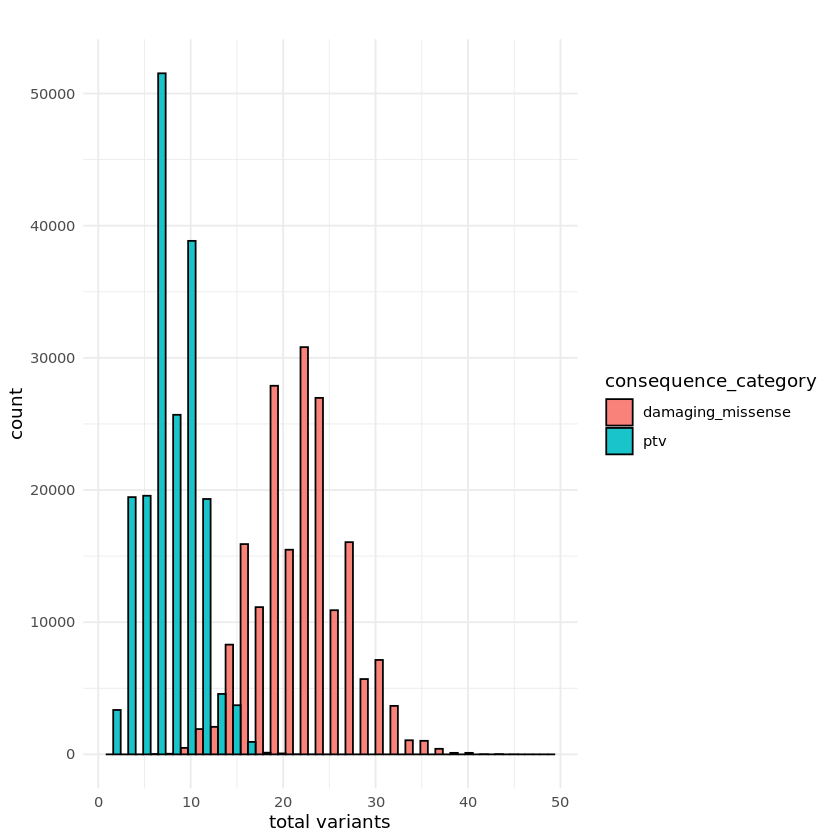

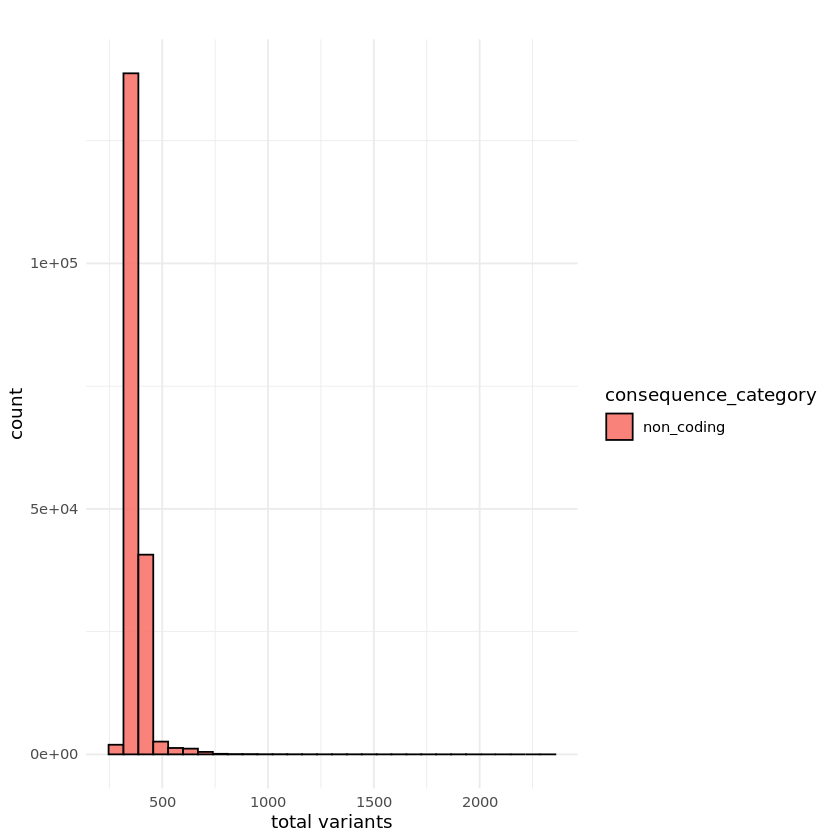

In [49]:
d <- snvs_by_iid
aggregate(total ~ consequence_category, data = d, FUN = median)
#hist(d[d$consequence_category == 'ptv',]$total)

ggplot(d[d$consequence_category %in% c('ptv','damaging_missense'),], aes(x=total, fill=consequence_category)) + 
    #geom_density(alpha = 0.7, color = 'black', adjust = 3) +
    geom_histogram(alpha = 0.9, color = 'black', position = 'dodge') +
    xlab('total variants') +
    ggtitle('') +
    theme_minimal()

ggplot(d[d$consequence_category %in% c('non_coding'),], aes(x=total, fill=consequence_category)) + 
    #geom_density(alpha = 0.7, color = 'black', adjust = 3) +
    geom_histogram(alpha = 0.9, color = 'black', position = 'dodge') +
    xlab('total variants') +
    ggtitle('') +
    theme_minimal()

In [58]:
categories

[1] "non_coding"        "damaging_missense" "other_missense"   
[4] "ptv"               "synonymous"

In [70]:

l <- length(unique(snvs_by_gene[snvs_by_gene$consequence_category %in% 'non_coding',]$Gene))
l


[1] 17853

In [23]:
dt <- as.data.table(table(d1$Gene,d1$consequence_category))
colnames(dt) <- c('gene','csqs_category','n')
head(dt)

gene,csqs_category,n
<chr>,<chr>,<int>
,damaging_missense,0
ENSG00000012779,damaging_missense,511
ENSG00000014919,damaging_missense,470
ENSG00000015171,damaging_missense,7
ENSG00000019995,damaging_missense,27
ENSG00000023041,damaging_missense,12


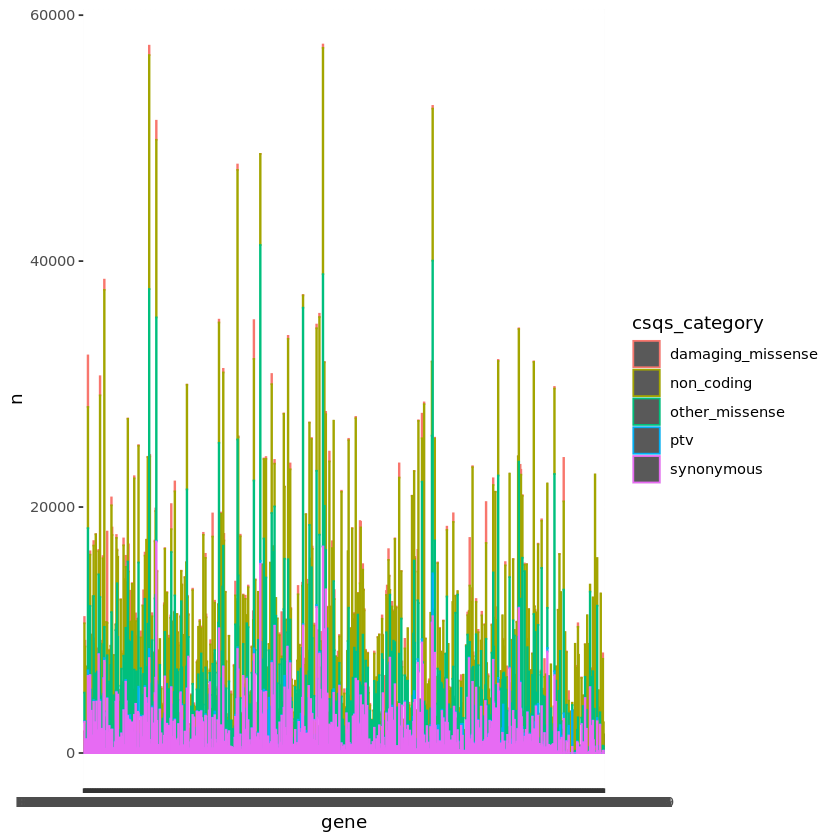

In [21]:
ggplot(dt, aes(x = gene, y = n, color = csqs_category)) + 
  geom_bar(stat='identity')

[1] "Gene"                 "consequence_category" "s"                   
[4] "n"                    "singletons"           "total"

Gene,consequence_category,s,n,singletons,total
<chr>,<chr>,<int>,<int>,<int>,<int>
,non_coding,1010963,1,0,1
,non_coding,1016162,1,0,1
,non_coding,1036900,1,0,1
,non_coding,1051342,1,0,1
,non_coding,1054362,1,0,1
,non_coding,1059455,1,0,1
,non_coding,1084796,1,0,1
,non_coding,1097669,1,0,1
,non_coding,1099323,1,0,1


In [50]:
length(samples)/190000 # looks like 4.3% of individuals are knockouts.. but there does not look like there any any singletons?

[1] 0.04307895

In [51]:
# get files
files = sort(list.files('../derived/knockouts/eur/missense_and_ptv/', full.names = TRUE, pattern = 'burden'))

In [56]:
# all singletons have been removed?
dt <- fread(files[21])
sum(dt$singletons > 0)

[1] 0

[1] 0

In [19]:
x = as.data.table(table(d$s, d$consequence_category))

V1,V2,N
<chr>,<chr>,<int>
1000028,damaging_missense,1
1000034,damaging_missense,1
1000087,damaging_missense,3
1000118,damaging_missense,1
1000120,damaging_missense,1
1000162,damaging_missense,1


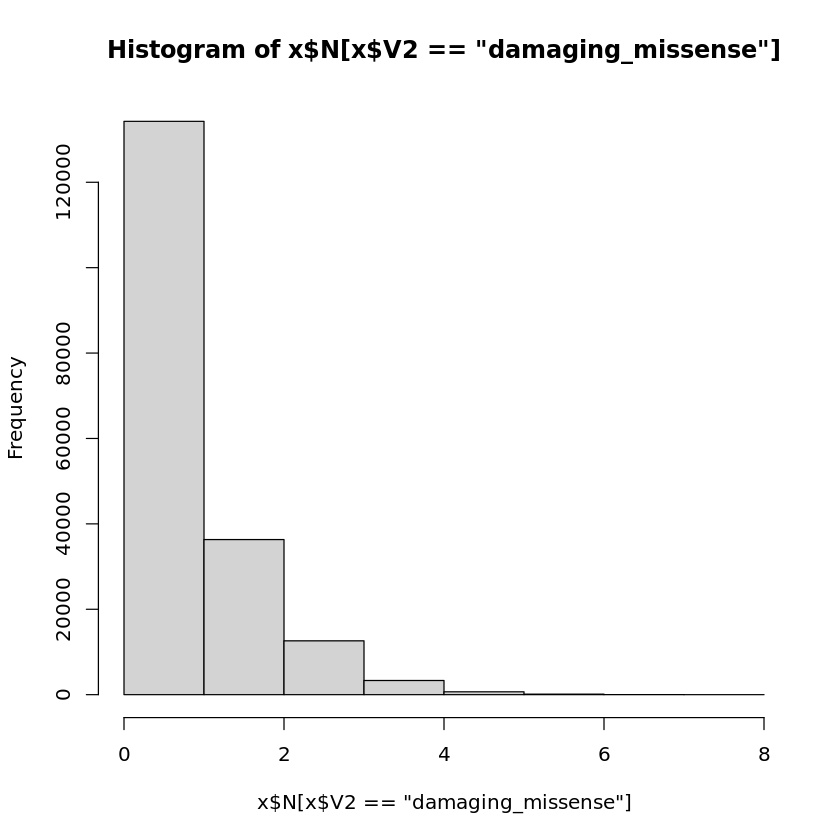

In [28]:
hist(x$N[x$V2=='damaging_missense'], breaks = 10)